## Emotion Classification with RNNs, LSTMs & GRUs

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

/opt/anaconda3/envs/sentiment/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## LOADING THE DATASET FROM HUGGINFACE


In [4]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [5]:
label_names = emotion_dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [7]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [8]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## Exploratory Data Analysis (EDA)

<Axes: xlabel='label', ylabel='count'>

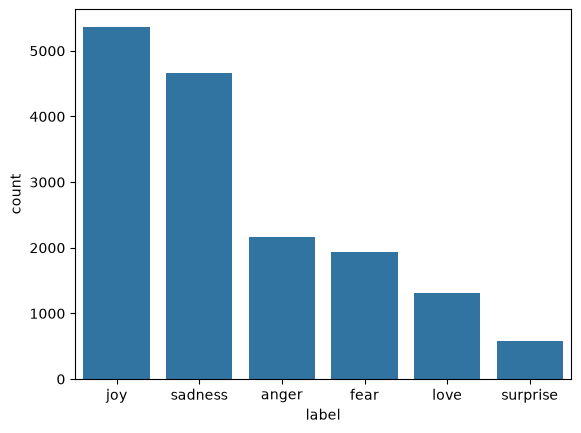

In [9]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [10]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

The dataset exhibits a significant class imbalance, dominated by positive emotions (joy at ~44.7%) and negative emotions (sadness at ~38.9%), which together make up over 83% of the training data. Minor categories like love and surprise are heavily underrepresented, with surprise constituting under 5% of the total samples. To prevent the model from biasing toward high-frequency classes, technique strategies such as class-weighted loss functions, stratified splitting, or resampling methods

##  Deep Learning Sequence Models

## Tokenize text, pad sequence to 50char, labels into numpy arrays

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


### Class Weighting

The training dataset exhibits significant class imbalance, with **Joy and Sadness** having substantially more samples than minority classes such as **Love and Surprise**. To reduce the model's tendency to favor the majority classes, balanced class weights are assigned during training.

Higher weights are given to underrepresented classes so that misclassifying them contributes more to the training loss. This helps the model learn all six emotions more fairly and complements the use of **Macro F1-score** during evaluation.


In [12]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [13]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Model 1 — Simple RNN

A plain, unidirectional Recurrent Neural Network (RNN) that processes the input sequence sequentially and serves as the foundational deep learning model for comparison with LSTM, GRU, and the advanced BiGRU architecture.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20


/opt/anaconda3/envs/sentiment/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.1654 - loss: 1.9359 - val_accuracy: 0.1035 - val_loss: 1.8176
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1477 - loss: 1.8149 - val_accuracy: 0.1815 - val_loss: 1.7784
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.1662 - loss: 1.7892 - val_accuracy: 0.1110 - val_loss: 1.8095
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1582 - loss: 1.7763 - val_accuracy: 0.1125 - val_loss: 1.7932
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1472 - loss: 1.7724 - val_accuracy: 0.1030 - val_loss: 1.8085
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1815 - loss: 1.7784
RNN Loss: 1.7783958911895752
RNN Accuracy: 0.18150000274181366


### Model 2 — Standard LSTM

A plain, unidirectional Long Short-Term Memory (LSTM) network designed to capture longer-term dependencies in the input sequences and provide a stronger sequential baseline than the Simple RNN.


In [15]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.1514 - loss: 1.7956 - val_accuracy: 0.0340 - val_loss: 1.8251
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.1538 - loss: 1.7939 - val_accuracy: 0.2895 - val_loss: 1.7805
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.1564 - loss: 1.7924 - val_accuracy: 0.1380 - val_loss: 1.7646
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.1641 - loss: 1.7950 - val_accuracy: 0.0365 - val_loss: 1.8175
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.1678 - loss: 1.7830 - val_accuracy: 0.0405 - val_loss: 1.7970
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.2189 - loss: 1.6926 - val_accuracy: 0.2125 - val_loss: 1.6134
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.2743 - loss: 1.4348 - val_accuracy: 0.2630 - val_loss: 1.4075
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.4715 - loss: 1.0910 - 

### Model 3 — Standard GRU

A plain, unidirectional Gated Recurrent Unit (GRU) network designed to capture sequential dependencies while using a simpler gating mechanism than LSTM, providing another foundational model for comparison with RNN and LSTM.


In [16]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.1779 - loss: 1.7957 - val_accuracy: 0.0330 - val_loss: 1.8152
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.1369 - loss: 1.7956 - val_accuracy: 0.1165 - val_loss: 1.7846
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.1728 - loss: 1.7939 - val_accuracy: 0.1370 - val_loss: 1.8115
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.1577 - loss: 1.7940 - val_accuracy: 0.0820 - val_loss: 1.8013
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.1597 - loss: 1.7914 - val_accuracy: 0.1460 - val_loss: 1.7956
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1165 - loss: 1.7846
GRU Loss: 1.7846442461013794
GRU Accuracy: 0.11649999767541885


### Ranking & Selection

Evaluate and rank the foundational RNN, LSTM, and GRU models based on their validation performance to identify the strongest recurrent architecture for further development in Phase 2.

In [17]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.407898,0.8800
0,RNN,1.778396,0.1815
2,GRU,1.784644,0.1165


### Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

In [18]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') 
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/opt/anaconda3/envs/sentiment/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 105ms/step - accuracy: 0.5692 - loss: 1.0459 - val_accuracy: 0.8865 - val_loss: 0.4113
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 110ms/step - accuracy: 0.9139 - loss: 0.2467 - val_accuracy: 0.9160 - val_loss: 0.2165
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step - accuracy: 0.9403 - loss: 0.1523 - val_accuracy: 0.9160 - val_loss: 0.2265
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 117ms/step - accuracy: 0.9578 - loss: 0.1086 - val_accuracy: 0.9225 - val_loss: 0.2099
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 113ms/step - accuracy: 0.9673 - loss: 0.0904 - val_accuracy: 0.9170 - val_loss: 0.2578
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - accuracy: 0.9741 - loss: 0.0720 - val_accuracy: 0.9115 - val_loss: 0.3072
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 119ms/step - accuracy: 0.9781 - loss: 0.0657 - val_accuracy: 0.9185 - val_loss: 0.2675


In [20]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9225 - loss: 0.2099
BiGRU Loss: 0.20991449058055878
BiGRU Accuracy: 0.9225000143051147


### Overall Evaluation & Bias Analysis


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


<Axes: >

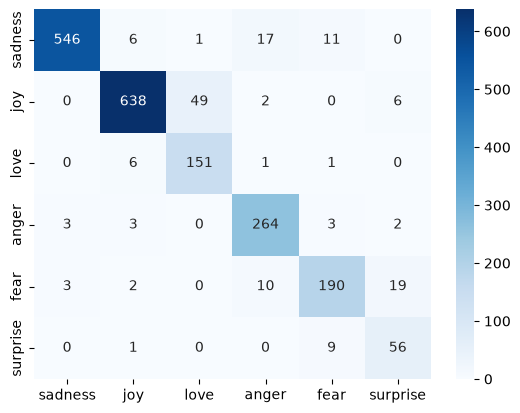

In [21]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)
sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

### Final Predictions
Test the winning model on unseen sample sentences.

In [22]:
sample_texts = [

    # Joy
    "After months of hard work, I finally got the job I had been dreaming about.",

    # Sadness
    "I tried to stay positive, but losing someone I cared about has left me feeling empty.",

    # Anger
    "I spent hours preparing everything, and they cancelled the meeting without even telling me.",

    # Fear
    "My heart started racing when I heard footsteps following me in the empty street.",

    # Surprise
    "I opened the door expecting a normal evening, but everyone was standing there waiting for me.",

    # Love
    "Even on my worst days, being around her makes me feel understood and cared for."

]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Text: After months of hard work, I finally got the job I had been dreaming about.
Predicted Emotion: joy
Text: I tried to stay positive, but losing someone I cared about has left me feeling empty.
Predicted Emotion: sadness
Text: I spent hours preparing everything, and they cancelled the meeting without even telling me.
Predicted Emotion: anger
Text: My heart started racing when I heard footsteps following me in the empty street.
Predicted Emotion: fear
Text: I opened the door expecting a normal evening, but everyone was standing there waiting for me.
Predicted Emotion: fear
Text: Even on my worst days, being around her makes me feel understood and cared for.
Predicted Emotion: sadness


In [ ]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) 

BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)